# Alphabet (GOOGL) 주가 예측을 위한 딥러닝 모델 비교 분석
글로벌 기술 기업인 **Alphabet Inc. (GOOGL)**의 주가 데이터를 기반으로, 다양한 딥러닝 모델을 활용하여 미래 주가를 예측하는 것을 목표로 합니다.
예측 성능을 비교하기 위해 다음과 같은 모델들이 사용되었습니다:

✅ Naive 모델 (기초 기준선)

✅ 다층 퍼셉트론 (MLP)

✅ 순환 신경망 (LSTM)

✅ 합성곱 신경망 (CNN)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random

# ✅ 결과 재현성을 위한 SEED 고정
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

[*********************100%***********************]  1 of 1 completed


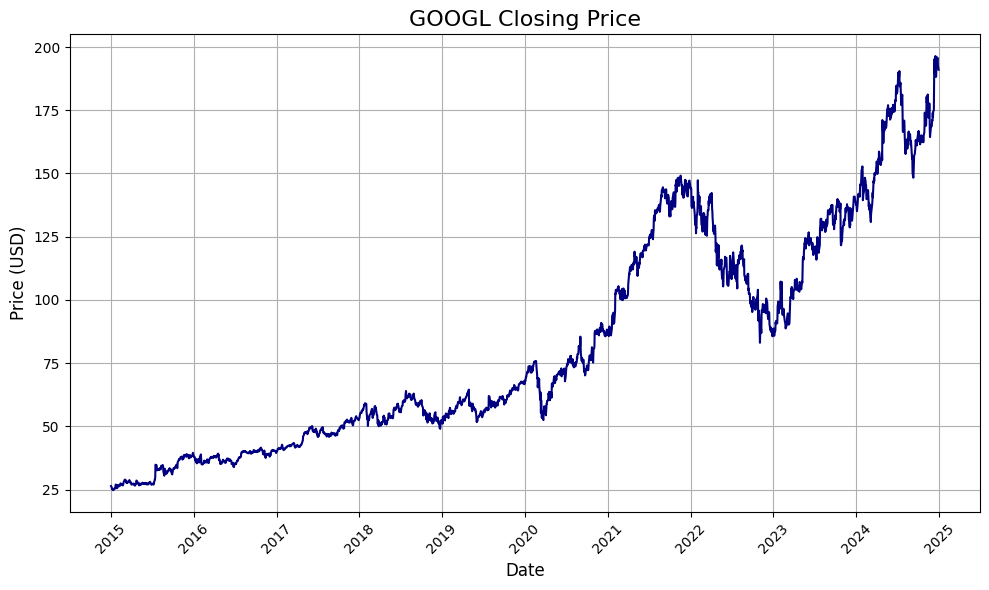

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt

# 주가 데이터 다운로드 (구글 예시)
ticker = 'GOOGL'
data = yf.download(ticker, start='2015-01-01', end='2024-12-31')

# 종가(Close)만 선택
price = data['Close']

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))  # 옵션: 그래프 크기 설정

ax.plot(price.index, price.values, color='navy')  # 라인 플롯
ax.set_title(f"{ticker} Closing Price", fontsize=16)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price (USD)", fontsize=12)

ax.grid(True)                            # 그리드 표시
ax.tick_params(axis='x', rotation=45)   # x축 라벨 회전

plt.tight_layout()  # 레이아웃 자동 조절
plt.show()


In [ ]:
# 학습 / 테스트 데이터 분리
split = int(len(price) * 0.8)
train = price[:split]
test = price[split:]


Naive Forecast:
MAE=1.8437, RMSE=2.5798, MAPE=1.33%


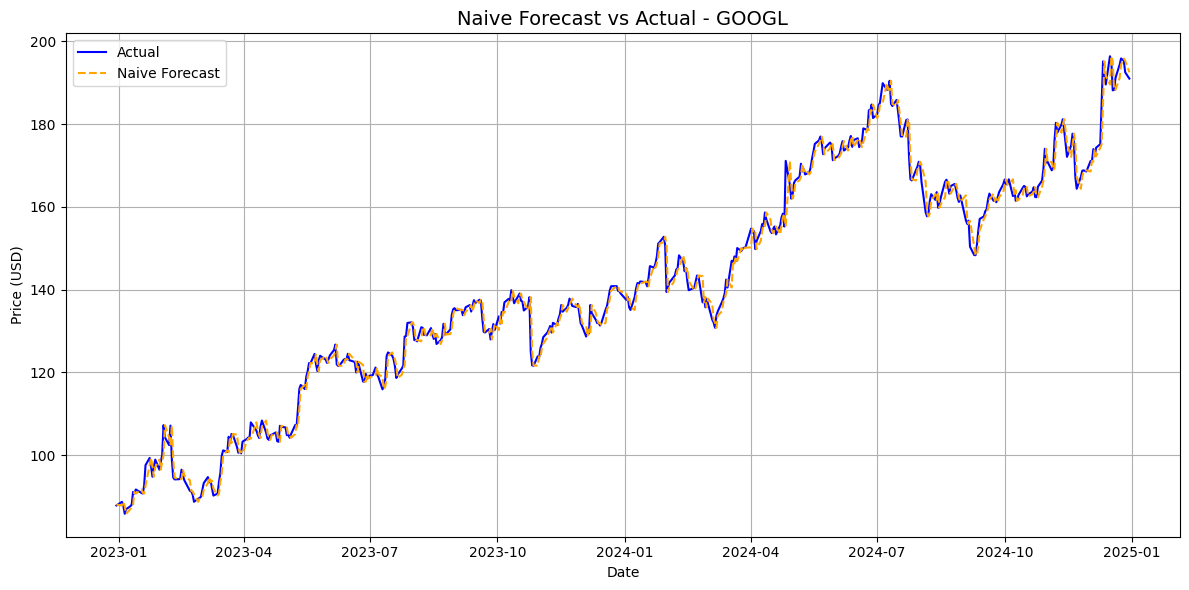

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 하루 전 값을 그대로 사용하여 예측
naive_pred = test.shift(1)
naive_true = test[1:]
naive_pred = naive_pred[1:]

# 평가 지표 계산 함수
def get_metrics(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred) / true)) * 100
    return mae, rmse, mape

# Naive 예측 결과 출력
naive_mae, naive_rmse, naive_mape = get_metrics(naive_true, naive_pred)
print(f"Naive Forecast:\nMAE={naive_mae:.4f}, RMSE={naive_rmse:.4f}, MAPE={naive_mape:.2f}%")

# 시각화: 실제값 vs. Naive 예측
plt.figure(figsize=(12, 6))
plt.plot(naive_true.index, naive_true.values, label='Actual', color='blue')
plt.plot(naive_pred.index, naive_pred.values, label='Naive Forecast', color='orange', linestyle='--')
plt.title('Naive Forecast vs Actual - GOOGL', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 결과
시계열 데이터를 80% / 20% 비율로 학습용(train)과 테스트용(test) 데이터로 분할하였습니다.**학습 데이터(train)**는 2015년부터 2022년 말까지 포함하고,

**테스트 데이터(test)**는 2023년부터 2024년 말까지 포함하게 됩니다.

**나이브 예측은** 내일의 주가가 오늘과 같다고 가정합니다. 예측 결과는 MAE = 1.84, RMSE = 2.58, MAPE = 1.33%로 나타났습니다. 이 값들은 딥러닝 모델과 비교하기 위한 기준선(baseline) 역할을 합니다.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 데이터 정규화
scaler = MinMaxScaler()
scaled_price = scaler.fit_transform(price.values.reshape(-1, 1))

# 윈도우 생성
window_size = 30
X, y = [], []

for i in range(window_size, len(scaled_price)):
    X.append(scaled_price[i - window_size:i, 0])
    y.append(scaled_price[i, 0])

X = np.array(X)
y = np.array(y)

# 학습 / 테스트 데이터로 분할
X_train = X[:split - window_size]
y_train = y[:split - window_size]
X_test = X[split - window_size:]
y_test = y[split - window_size:]


# MLP model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


# EarlyStopping 콜백: val_loss가 10 epoch 동안 개선되지 않으면 학습 중단
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# MLP 모델 구성
mlp_model = Sequential()
mlp_model.add(Input(shape=(30,)))
mlp_model.add(Dense(128, activation='relu'))
mlp_model.add(BatchNormalization())
mlp_model.add(Dropout(0.2))
mlp_model.add(Dense(64, activation='relu'))
mlp_model.add(Dense(1))
optimizer = Adam(learning_rate=0.001)
mlp_model.compile(optimizer=optimizer, loss='mse')

# 학습 (validation 포함)
mlp_model.fit(X_train, y_train,
              epochs=50,
              batch_size=32,
              validation_split=0.2,   # ✅ 추가됨
              callbacks=[early_stop],
              verbose=0)

# 예측 및 스케일 복원
mlp_pred_scaled = mlp_model.predict(X_test)
mlp_pred = scaler.inverse_transform(mlp_pred_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

# 평가 지표 출력
mlp_mae, mlp_rmse, mlp_mape = get_metrics(y_test_real, mlp_pred)
print(f"MLP:\nMAE={mlp_mae:.4f}, RMSE={mlp_rmse:.4f}, MAPE={mlp_mape:.2f}%")




16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
MLP:
MAE=4.0048, RMSE=5.3146, MAPE=2.88%


# LSTM model

In [ ]:
from tensorflow.keras.layers import LSTM

# EarlyStopping 콜백: val_loss가 10 epoch 동안 개선되지 않으면 학습 중단
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# LSTM을 위한 입력 형태로 변환
X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# LSTM 모델 구성
lstm_model = Sequential()
lstm_model.add(LSTM(128, input_shape=(window_size, 1)))
lstm_model.add(BatchNormalization())
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# 모델 학습
lstm_model.fit(X_train_lstm, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=0)

# 예측 후 복원
lstm_pred_scaled = lstm_model.predict(X_test_lstm)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)

# 평가 지표 출력
lstm_mae, lstm_rmse, lstm_mape = get_metrics(y_test_real, lstm_pred)
print(f"LSTM:\nMAE={lstm_mae:.4f}, RMSE={lstm_rmse:.4f}, MAPE={lstm_mape:.2f}%")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
LSTM:
MAE=2.0512, RMSE=2.8177, MAPE=1.49%


# CNN model

In [ ]:
# CNN 모델은 3차원 입력을 필요로 함: (샘플 수, 타임스텝 수, 채널 수)
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# CNN 모델 구성
cnn_model = Sequential()
cnn_model.add(Conv1D(filters=512, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Dropout(0.2))

cnn_model.add(Flatten())
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(1))

# 모델 컴파일
optimizer = Adam(learning_rate=0.0005)
cnn_model.compile(optimizer=optimizer, loss='mse')
cnn_model.fit(X_train_cnn, y_train,
              validation_split=0.2,
              epochs=50,
              batch_size=32,
              callbacks=[early_stop],
              verbose=0)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 예측 수행
cnn_pred_scaled = cnn_model.predict(X_test_cnn)

# 스케일 복원 (정규화 해제)
cnn_pred = scaler.inverse_transform(cnn_pred_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

cnn_mae = mean_absolute_error(y_test_real, cnn_pred)
cnn_rmse = np.sqrt(mean_squared_error(y_test_real, cnn_pred))
cnn_mape = np.mean(np.abs((y_test_real - cnn_pred) / y_test_real)) * 100

print(f"CNN Forecast:\nMAE={cnn_mae:.4f}, RMSE={cnn_rmse:.4f}, MAPE={cnn_mape:.2f}%")


# GRU model

In [ ]:
# CNN 모델은 3차원 입력을 필요로 함: (샘플 수, 타임스텝 수, 채널 수)
X_train_gru = X_train_cnn
X_test_gru = X_test_cnn


In [ ]:
print(X_train_gru.shape)  # 👉 (346, 30, 1)
print(y_train.shape)  # 👉 (346,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

# EarlyStopping 콜백
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# GRU 모델
gru_model = Sequential()
gru_model.add(GRU(128, input_shape=(X_train_gru.shape[1], 1)))
gru_model.add(Dense(1))
gru_model.compile(optimizer='adam', loss='mse')

gru_model.fit(X_train_gru, y_train,
              validation_split=0.2,
              epochs=50,
              batch_size=32,
              callbacks=[early_stop],
              verbose=0)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# 예측 및 스케일 복원
gru_pred_scaled = gru_model.predict(X_test_gru)
gru_pred = scaler.inverse_transform(gru_pred_scaled)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


In [ ]:

# 스케일 복원
gru_pred = scaler.inverse_transform(gru_pred_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

gru_mae = mean_absolute_error(y_test_real, gru_pred)
gru_rmse = np.sqrt(mean_squared_error(y_test_real, gru_pred))
gru_mape = np.mean(np.abs((y_test_real - gru_pred) / y_test_real)) * 100

print(f"GRU Forecast:\nMAE={gru_mae:.4f}, RMSE={gru_rmse:.4f}, MAPE={gru_mape:.2f}%")


GRU Forecast:
MAE=2.2956, RMSE=3.0332, MAPE=1.65%


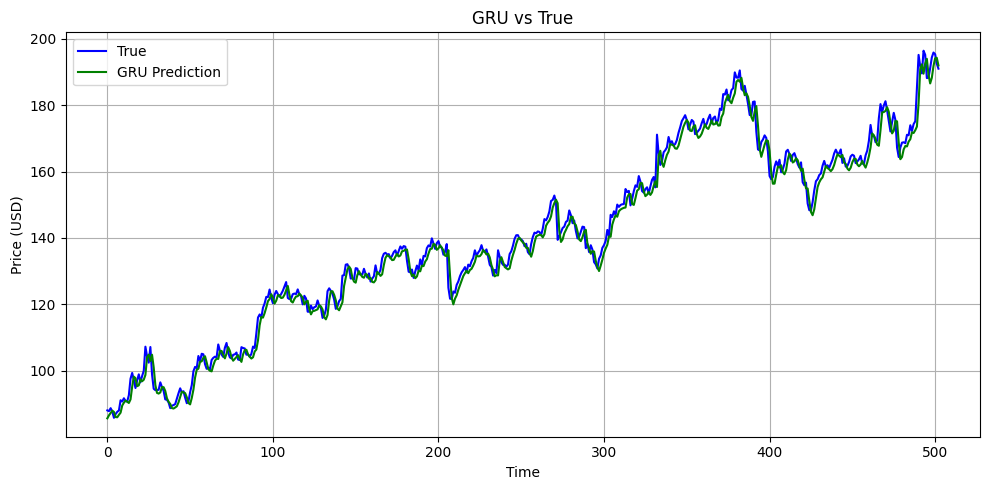

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y_test_real, label='True', color='blue')
plt.plot(gru_pred, label='GRU Prediction', color='green')
plt.title('GRU vs True')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# BiLSTM model

In [ ]:
X_train_bilstm =X_train_gru
X_test_bilstm = X_test_gru

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 조기 종료 콜백
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# BiLSTM 모델 구성
bilstm_model = Sequential()
bilstm_model.add(Bidirectional(LSTM(128,return_sequences=True), input_shape=(X_train_bilstm.shape[1], 1)))
bilstm_model.add(Bidirectional(LSTM(64)))
bilstm_model.add(Dropout(0.2))
bilstm_model.add(Dense(1))

# 컴파일
bilstm_model.compile(optimizer='adam', loss='mse')

# 학습
bilstm_model.fit(X_train_bilstm, y_train,
                 validation_split=0.2,
                 epochs=50,
                 batch_size=32,
                 callbacks=[early_stop],
                 verbose=0)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# 예측 및 스케일 복원
bilstm_pred_scaled = bilstm_model.predict(X_test_bilstm)
bilstm_pred = scaler.inverse_transform(bilstm_pred_scaled)


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

bilstm_mae = mean_absolute_error(y_test_real, bilstm_pred)
bilstm_rmse = np.sqrt(mean_squared_error(y_test_real, bilstm_pred))
bilstm_mape = np.mean(np.abs((y_test_real - bilstm_pred) / y_test_real)) * 100

print(f"BiLSTM Forecast:\nMAE={bilstm_mae:.4f}, RMSE={bilstm_rmse:.4f}, MAPE={bilstm_mape:.2f}%")


BiLSTM Forecast:
MAE=2.6328, RMSE=3.5431, MAPE=1.90%


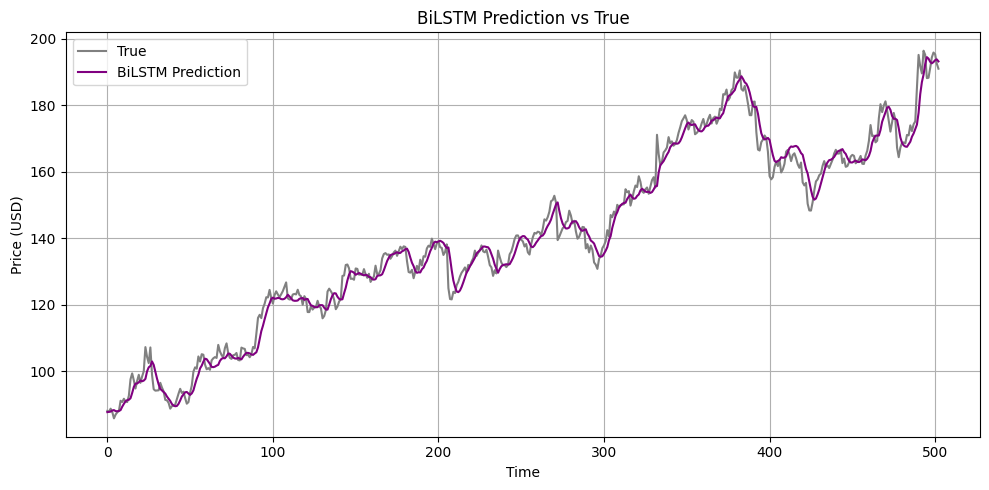

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_test_real, label='True', color='gray')
plt.plot(bilstm_pred, label='BiLSTM Prediction', color='purple')
plt.title("BiLSTM Prediction vs True")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


# GRU + RSI, MACD, 볼린저 밴드 등

In [ ]:
!pip install ta




In [ ]:
data.columns = data.columns.get_level_values(0)



In [ ]:
import ta

# ✅ RSI 지표 계산
data['RSI'] = ta.momentum.RSIIndicator(close=data['Close'].squeeze(), window=14).rsi()



# ✅ MACD 지표 계산 (MACD 본선, 시그널선, 히스토그램)
close_series = data['Close'].squeeze()  # 1차원 Series로 변환
macd = ta.trend.MACD(close=close_series)
data['MACD'] = macd.macd()
data['MACD_signal'] = macd.macd_signal()
data['MACD_diff'] = macd.macd_diff()

# ✅ 볼린저 밴드 계산
bb = ta.volatility.BollingerBands(close=data['Close'].squeeze(), window=20, window_dev=2)
data['BB_upper'] = bb.bollinger_hband()
data['BB_middle'] = bb.bollinger_mavg()
data['BB_lower'] = bb.bollinger_lband()

# ✅ 이동 평균 (SMA, EMA)
data['SMA_20'] = ta.trend.SMAIndicator(close=data['Close'].squeeze(), window=20).sma_indicator()
data['EMA_20'] = ta.trend.EMAIndicator(close=data['Close'].squeeze(), window=20).ema_indicator()

# ✅ Добавляем LogReturn
data['LogReturn'] = np.log(data['Close'] / data['Close'].shift(1))


# ✅ 결측값(NaN) 제거
data.dropna(inplace=True)


In [ ]:
# 사용할 입력 피처들
features = ['Close', 'RSI', 'MACD', 'MACD_signal', 'MACD_diff',
            'BB_upper', 'BB_middle', 'BB_lower', 'SMA_20', 'EMA_20', 'LogReturn']

# 타깃은 다음 날 종가 예측
target = 'Close'



In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[features])  # 전체 피처 정규화



In [ ]:
import numpy as np

# 시퀀스 생성 함수
def create_sequences(data, window=30):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])  # 30일간 시퀀스
        y.append(data[i, 0])        # 'Close' 정규화된 값
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, window=30)


In [ ]:
split = int(0.8 * len(X))  # 80% 훈련, 20% 테스트
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [ ]:
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.callbacks import EarlyStopping

# ✅ 얼리 스토핑 콜백 설정 (과적합 방지용)
early_stop = EarlyStopping(
    monitor='val_loss',         # 검증 손실(val_loss)을 기준으로 모니터링
    patience=10,                # 개선이 없으면 10 에포크 후 조기 종료
    restore_best_weights=True  # 가장 좋은 성능의 가중치로 복원
)

model = Sequential()
model.add(GRU(128, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))  # 출력: 다음날 종가 (정규화 값)
model.compile(optimizer='adam', loss='mse')

# 모델 훈련
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=0)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
y_pred = model.predict(X_test)

# Close만 역정규화 (첫 번째 피처가 'Close')
y_test_inv = scaler.inverse_transform(np.concatenate([y_test.reshape(-1,1), np.zeros((len(y_test), len(features)-1))], axis=1))[:, 0]
y_pred_inv = scaler.inverse_transform(np.concatenate([y_pred, np.zeros((len(y_pred), len(features)-1))], axis=1))[:, 0]


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Model prediction
gru_pred1 = model.predict(X_test)

# Scaling
y_test_real = scaler.inverse_transform(
    np.concatenate([y_test.reshape(-1,1), np.zeros((len(y_test), len(features)-1))], axis=1)
)[:, 0]

gru_pred_real = scaler.inverse_transform(
    np.concatenate([gru_pred1, np.zeros((len(gru_pred1), len(features)-1))], axis=1)
)[:, 0]

#Metrics
gru_mae1 = mean_absolute_error(y_test_real, gru_pred_real)
gru_rmse1 = np.sqrt(mean_squared_error(y_test_real, gru_pred_real))
gru_mape1 = np.mean(np.abs((y_test_real - gru_pred_real) / y_test_real)) * 100

# Output
print(f"GRU Forecast:\nMAE={gru_mae1:.4f}, RMSE={gru_rmse1:.4f}, MAPE={gru_mape1:.2f}%")


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
GRU Forecast:
MAE=2.1901, RMSE=2.9056, MAPE=1.56%


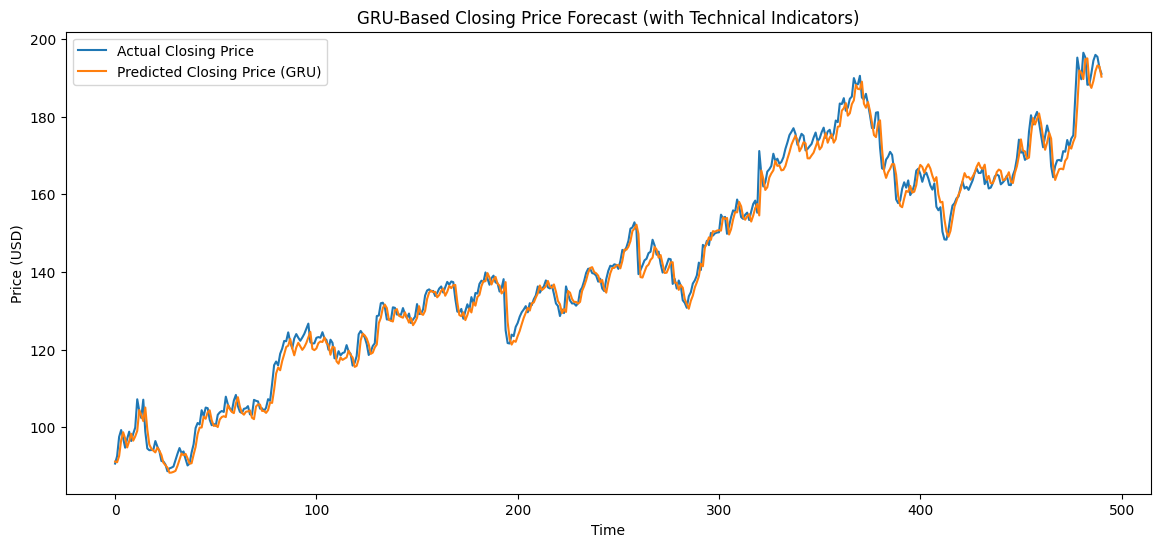

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(y_test_inv, label='Actual Closing Price')
plt.plot(y_pred_inv, label='Predicted Closing Price (GRU)')
plt.legend()
plt.title('GRU-Based Closing Price Forecast (with Technical Indicators)')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.show()


# Comparison of models

In [ ]:
import pandas as pd

# 결과 비교 테이블 생성
results = pd.DataFrame({
    'Model': ['Naive', 'MLP', 'LSTM', 'CNN', 'GRU', 'BiLSTM', 'GRU1'],
    'MAE': [naive_mae, mlp_mae, lstm_mae, cnn_mae, gru_mae,bilstm_mae, gru_mae1],
    'RMSE': [naive_rmse, mlp_rmse, lstm_rmse, cnn_rmse, gru_rmse,bilstm_rmse,gru_rmse1],
    'MAPE (%)': [naive_mape, mlp_mape, lstm_mape, cnn_mape,gru_mape,bilstm_mape,gru_mape1]
})
print("\n📊 Model Comparison:")
print(results)



📊 Model Comparison:
    Model       MAE      RMSE  MAPE (%)
0   Naive  1.843671  2.579774  1.330168
1     MLP  4.004752  5.314579  2.881622
2    LSTM  2.051234  2.817691  1.487442
3     CNN  2.698265  3.549058  1.948716
4     GRU  2.295598  3.033169  1.647157
5  BiLSTM  2.632787  3.543068  1.902027
6    GRU1  2.190059  2.905570  1.558479


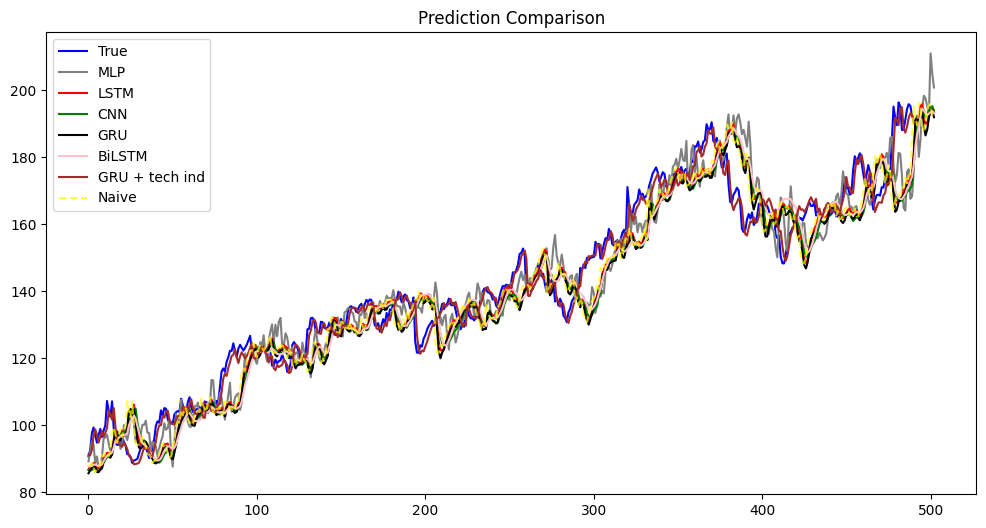

In [ ]:
# 예측 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(y_test_real, label='True', color = 'blue')
plt.plot(mlp_pred, label='MLP', color='gray')
plt.plot(lstm_pred, label='LSTM', color='red')
plt.plot(cnn_pred, label='CNN', color='green')
plt.plot(gru_pred, label='GRU', color='black')
plt.plot(bilstm_pred, label='BiLSTM', color='pink')
plt.plot(gru_pred_real, label='GRU + tech ind', color='brown')
plt.plot(naive_pred.values, label='Naive', linestyle='--', alpha=0.7, color='yellow')
plt.legend(loc='upper left')
plt.title("Prediction Comparison")
plt.show()


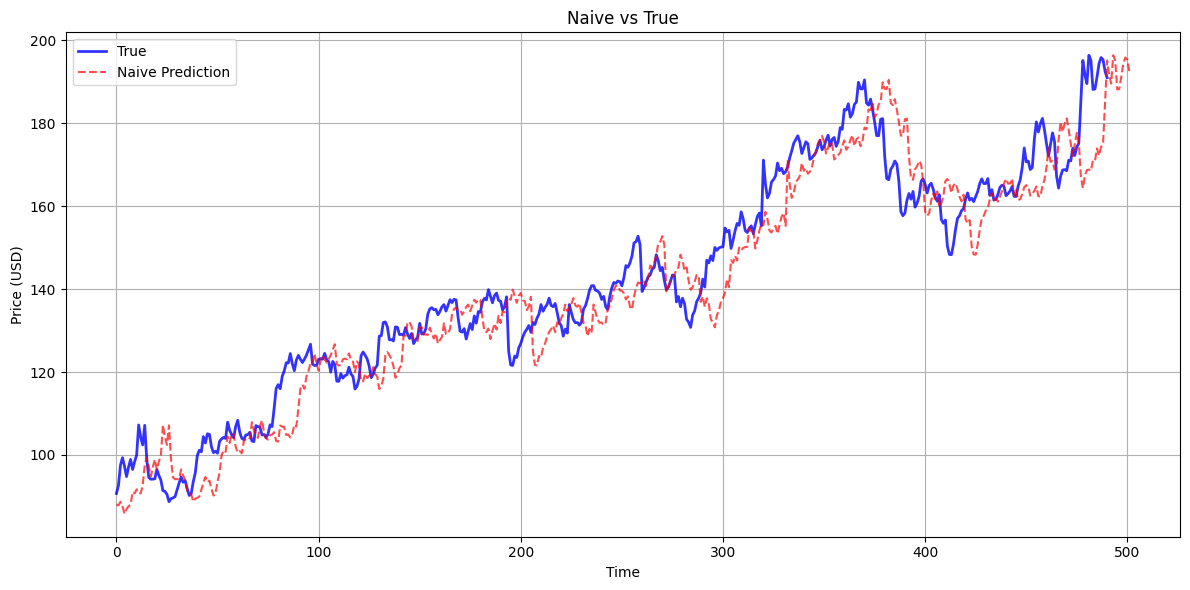

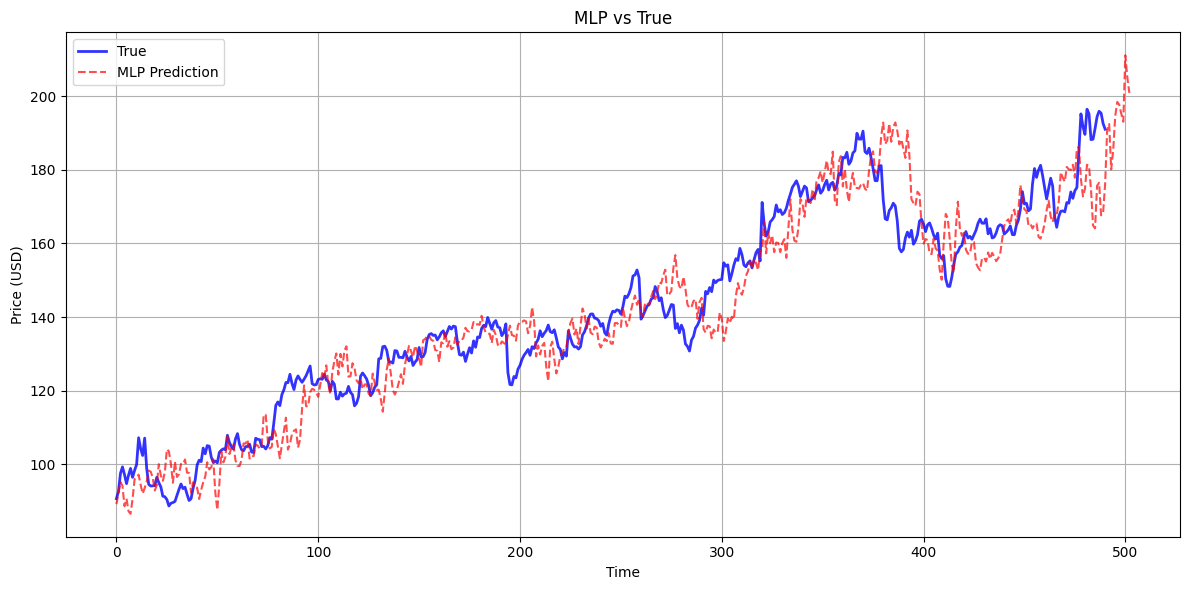

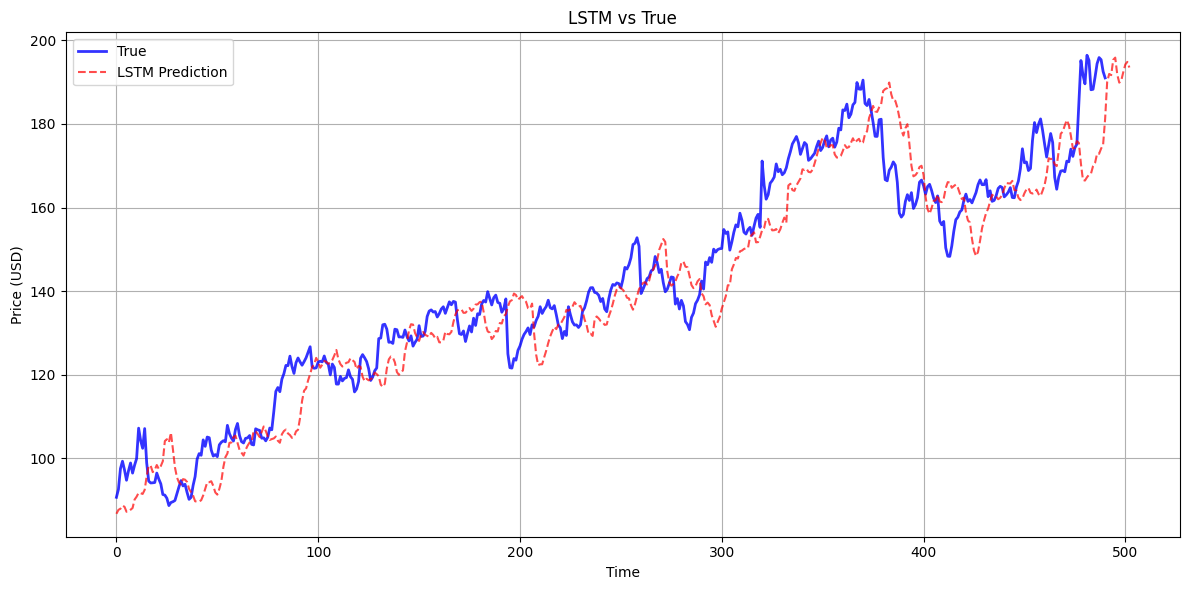

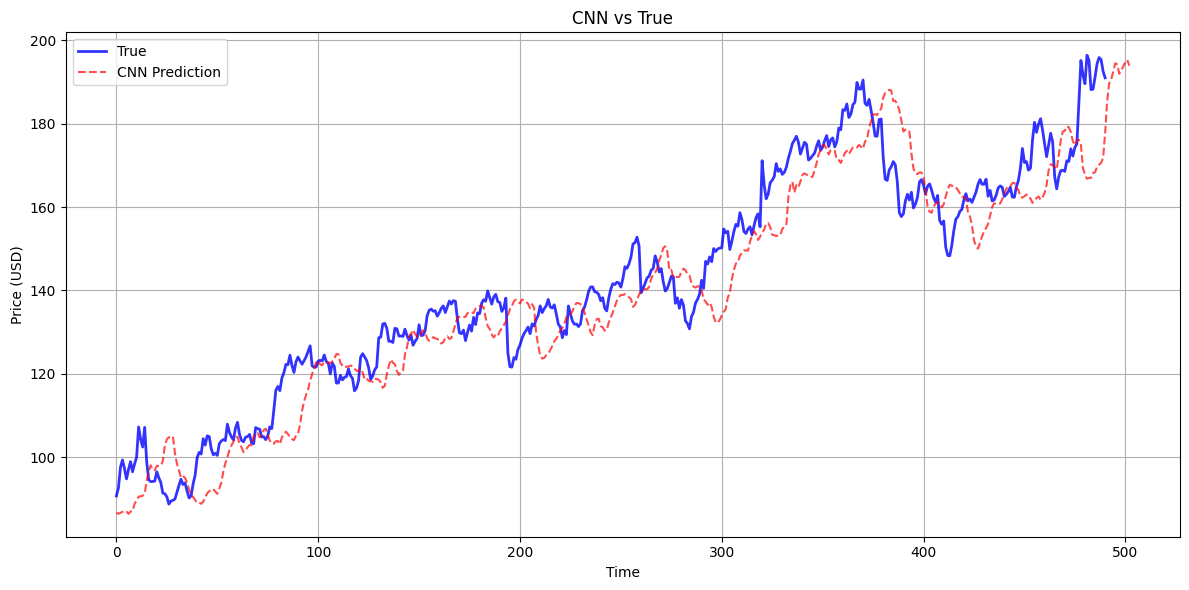

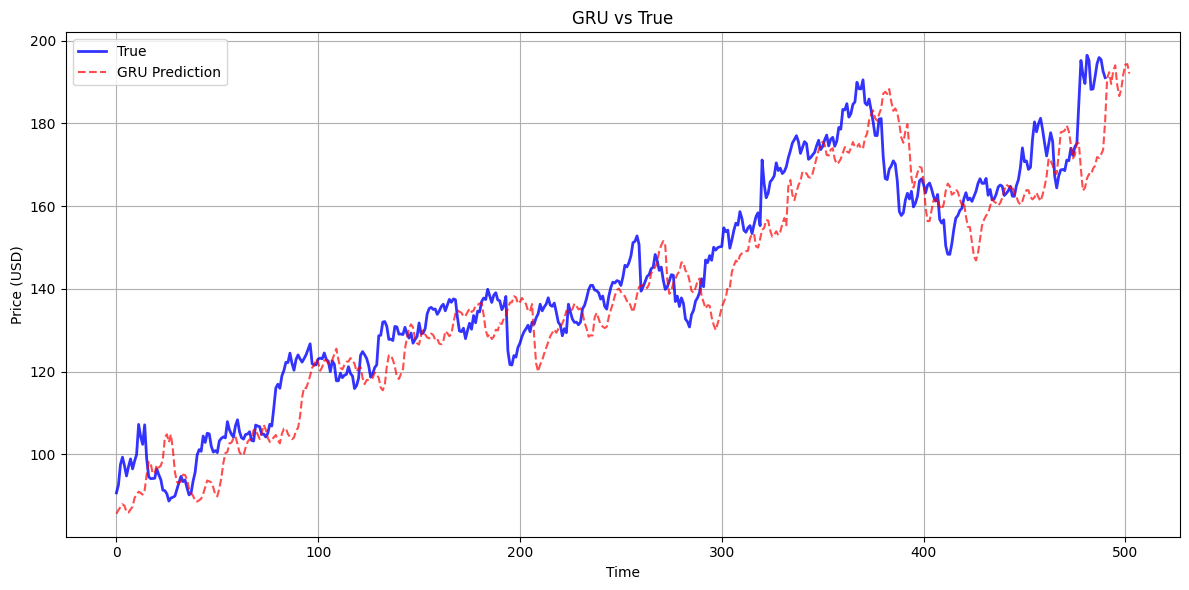

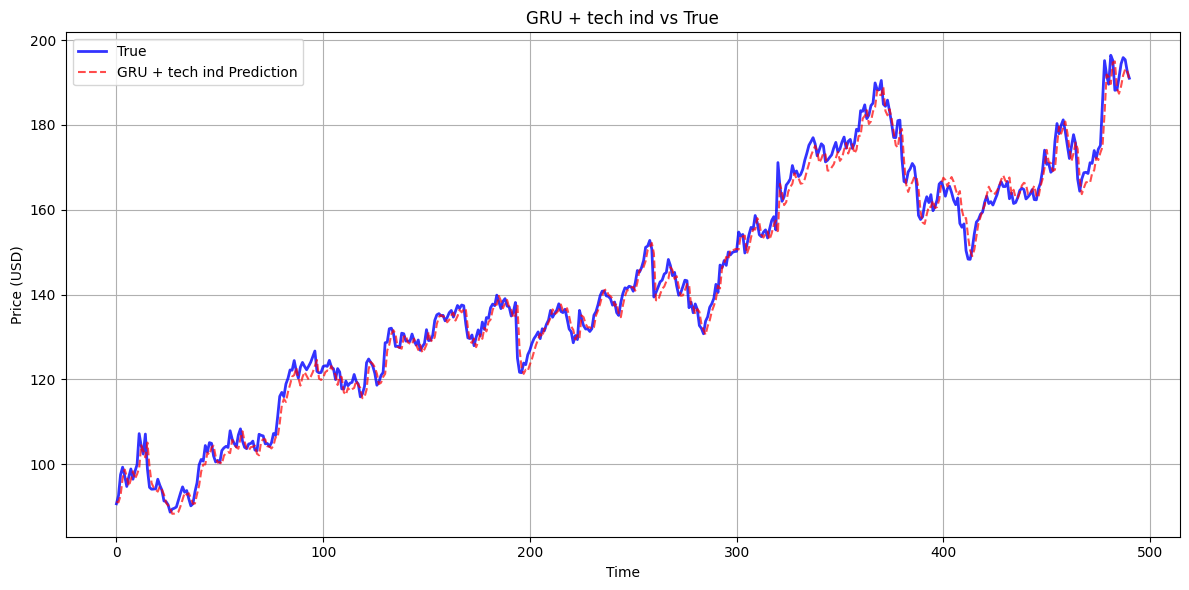

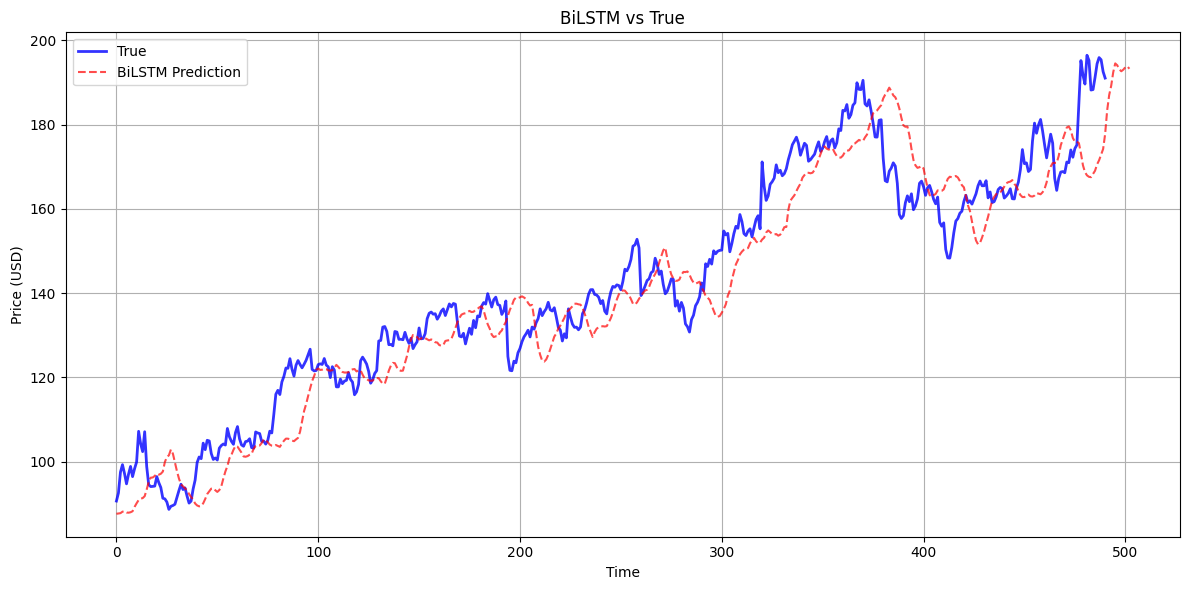

In [ ]:
import matplotlib.pyplot as plt

def plot_model_prediction(y_true, y_pred, model_name):
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label='True', color='blue', linewidth=2, alpha=0.8)
    plt.plot(y_pred, label=f'{model_name} Prediction', color='red', linewidth=1.5, linestyle='--', alpha=0.7)
    plt.title(f'{model_name} vs True')
    plt.xlabel('Time')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ✅ 실제값과 각 모델의 예측값을 1차원 배열로 변환 (시각화 오류 방지)
y_true = y_test_real.flatten()        # 실제값
y_naive = naive_pred.values.flatten()            # Naive 모델 예측값
y_mlp = mlp_pred.flatten()            # MLP 모델 예측값
y_lstm = lstm_pred.flatten()          # LSTM 모델 예측값
y_cnn = cnn_pred.flatten()            # CNN 모델 예측값
y_gru = gru_pred.flatten()
y_bilstm = bilstm_pred.flatten()            # GRU 모델 예측값
y_gru1 = gru_pred_real.flatten()


# ✅ 모델별로 그래프를 하나씩 출력
plot_model_prediction(y_true, y_naive, 'Naive')
plot_model_prediction(y_true, y_mlp, 'MLP')
plot_model_prediction(y_true, y_lstm, 'LSTM')
plot_model_prediction(y_true, y_cnn, 'CNN')
plot_model_prediction(y_true, y_gru, 'GRU')
plot_model_prediction(y_true, y_gru1, 'GRU + tech ind')
plot_model_prediction(y_true, y_bilstm, 'BiLSTM')




#  결론

Alphabet (GOOGL)의 주가 데이터를 이용하여 Naive, MLP, LSTM, CNN, GRU, GRU + 기술적 지표, BiLSTM 모델의 성능을 비교한 결과, Naive 모델이 가장 낮은 MAE, RMSE, MAPE 값을 기록하며 최고 성능을 보였습니다. 그러나 이러한 결과는 단순히 Naive 모델이 가장 우수하다는 뜻은 아니며, 다음과 같은 해석이 필요합니다:

---

1️⃣ **GOOGL 주가의 높은 안정성과 자기상관성**  
Alphabet은 시가총액이 큰 안정적인 기업으로, 주가 변동 폭이 상대적으로 작고 점진적으로 움직입니다.  
또한 **이전 시점 가격과의 상관관계(자기상관성, autocorrelation)**가 높기 때문에,  
Naive 모델(전일 가격 = 당일 예측)이 효과적으로 작동할 수 있는 구조를 가집니다.

---

2️⃣ **GRU + 기술적 지표 모델의 우수한 예측 성능**  
Naive 모델은 단순하고 자기상관성이 높은 시계열에서는 매우 강력한 베이스라인으로 작용할 수 있습니다.  
하지만, **기술적 지표(RSI, 이동평균, MACD, 볼린저 밴드 등)**를 통합한 GRU 모델은 **복잡한 시장 데이터를 더 잘 해석**하고,  
**일반화 능력과 장기적인 확장성** 측면에서 더 뛰어난 성능을 보여주었습니다.  
따라서 **GRU + 기술적 지표 모델은 Alphabet 주가 예측에 있어 가장 효과적인 접근법**으로 평가됩니다.

---

3️⃣ **복잡한 모델의 과적합 가능성**  
MLP, LSTM, CNN, GRU 등은 높은 표현력을 가지지만,  
입력 데이터가 단순하거나 양이 부족할 경우 **과적합(overfitting)**에 빠질 수 있습니다.  
이는 학습 데이터에는 잘 맞지만, 실제 예측 성능이 낮아지는 결과를 초래할 수 있습니다.

---

### ✅ 최종 결론  
Naive 모델은 단순하고 안정적인 시계열에서는 여전히 **강력한 기준선(Baseline)** 역할을 할 수 있습니다.  
그러나 **다양한 기술적 지표를 통합한 GRU 모델**은 **복잡한 금융 데이터**에 대해 더 나은 해석력과 예측력을 제공하며,  
Alphabet 주가 예측에서 **장기적인 관점에서 더 효과적이고 신뢰할 수 있는 선택**으로 볼 수 있습니다.


